In [2]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path
 
sns.set_theme(style="whitegrid", palette="muted")
 
nodes_df = pd.read_csv("kg_output/kg_nodes.csv")
edges_df = pd.read_csv("kg_output/kg_edges.csv")
 
print(f"Nodes : {len(nodes_df):,}")
print(f"Edges : {len(edges_df):,}")

# 又要导入包，真无聊

Matplotlib is building the font cache; this may take a moment.


Nodes : 3,449
Edges : 4,889


In [3]:
img   = nodes_df[nodes_df.label == "FundusImage"].copy()
od    = nodes_df[nodes_df.label == "OpticDisc"].copy()
rim   = nodes_df[nodes_df.label == "NeuralRim"].copy()
path  = nodes_df[nodes_df.label == "Pathology"].copy()
diag  = nodes_df[nodes_df.label == "Diagnosis"].copy()
 
print("=== FundusImage ===")
print(img["annotation"].value_counts())
print("\n=== Train / Test split ===")
print(img["split"].value_counts())

# 先分类各大的节点

=== FundusImage ===
annotation
glaucoma    427
normal      262
Name: count, dtype: int64

=== Train / Test split ===
split
train    589
test     100
Name: count, dtype: int64


In [5]:
NODE_COLS = {
    "FundusImage": ["filename", "annotation", "bin_label", "split"],
    "OpticDisc":   ["optic_disc_size", "cup_to_disc_ratio", "sharp_edge"],
    "NeuralRim":   ["neuroretinal_rim", "isnt_rule_followed", "rim_pallor",
                    "rim_color", "rim_thinning"],
    "Pathology":   ["bayoneting", "notching", "laminar_dot_sign"],
    "Diagnosis":   ["annotation", "risk_assessment", "confidence"],
}
 
def missing_report_fixed(df_all, node_label, own_cols):
    sub = df_all[df_all.label == node_label].copy()
    # 只保留该节点应有的列（且列存在于 DataFrame 中）
    cols = [c for c in own_cols if c in sub.columns]
    sub  = sub[cols]
    total = len(sub)
    miss  = sub.isnull().sum()
    pct   = (miss / total * 100).round(1)
    report = pd.DataFrame({"missing_n": miss, "missing_%": pct})
    report = report[report.missing_n > 0].sort_values("missing_%", ascending=False)
    if report.empty:
        print(f"[{node_label}] 无缺失值 ✓  ({total} rows)")
    else:
        print(f"[{node_label}] ({total} rows) 缺失情况：")
        print(report.to_string())
    print()
 
for label, cols in NODE_COLS.items():
    missing_report_fixed(nodes_df, label, cols)

# 数据是否确实。肯定要质量检查

[FundusImage] 无缺失值 ✓  (689 rows)

[OpticDisc] 无缺失值 ✓  (689 rows)

[NeuralRim] 无缺失值 ✓  (689 rows)

[Pathology] 无缺失值 ✓  (689 rows)

[Diagnosis] 无缺失值 ✓  (689 rows)



In [6]:
img_ann = img.set_index("id")["annotation"].to_dict()
 
# img_id -> diag_id (via HAS_DIAGNOSIS edge)
has_diag = edges_df[edges_df.rel == "HAS_DIAGNOSIS"][["src", "dst"]].rename(
    columns={"src": "img_id", "dst": "diag_id"}
)
# img_id -> od_id
has_od = edges_df[edges_df.rel == "HAS_OPTIC_DISC"][["src", "dst"]].rename(
    columns={"src": "img_id", "dst": "od_id"}
)
# img_id -> rim_id
has_rim = edges_df[edges_df.rel == "HAS_RIM"][["src", "dst"]].rename(
    columns={"src": "img_id", "dst": "rim_id"}
)
# img_id -> path_id
has_path = edges_df[edges_df.rel == "HAS_PATHOLOGY"][["src", "dst"]].rename(
    columns={"src": "img_id", "dst": "path_id"}
)
 
# master table
master = (
    has_diag
    .merge(has_od,   on="img_id")
    .merge(has_rim,  on="img_id")
    .merge(has_path, on="img_id")
)
master["annotation"] = master["img_id"].map(img_ann)
 
# join biomarker columns
master = (
    master
    .merge(od[["id","cup_to_disc_ratio","optic_disc_size","sharp_edge"]].rename(columns={"id":"od_id"}),  on="od_id")
    .merge(rim[["id","isnt_rule_followed","rim_pallor","rim_thinning","rim_color"]].rename(columns={"id":"rim_id"}), on="rim_id")
    .merge(path[["id","bayoneting","notching","laminar_dot_sign"]].rename(columns={"id":"path_id"}), on="path_id")
    .merge(diag[["id","risk_assessment","confidence"]].rename(columns={"id":"diag_id"}), on="diag_id")
)
 
print(f"Master table: {len(master)} rows x {len(master.columns)} cols")
print(master["annotation"].value_counts())

# 图连接以及标签对齐

Master table: 689 rows x 18 cols
annotation
glaucoma    427
normal      262
Name: count, dtype: int64


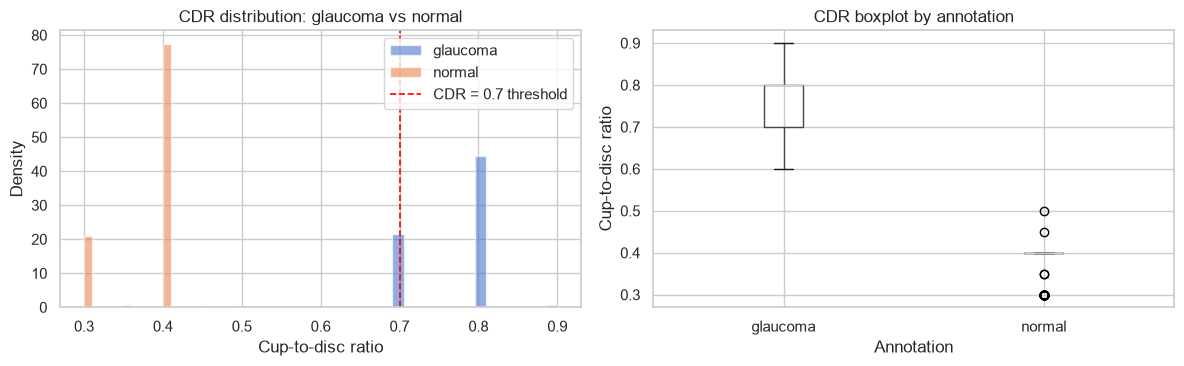


CDR 统计 by annotation:
            count   mean    std  min  25%  50%  75%  max
annotation                                              
glaucoma    427.0  0.768  0.049  0.6  0.7  0.8  0.8  0.9
normal      262.0  0.379  0.042  0.3  0.4  0.4  0.4  0.5


In [7]:
master["cup_to_disc_ratio"] = pd.to_numeric(master["cup_to_disc_ratio"], errors="coerce")
 
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
 
# histogram
for ann, grp in master.groupby("annotation"):
    axes[0].hist(
        grp["cup_to_disc_ratio"].dropna(),
        bins=20, alpha=0.6, label=ann, density=True
    )
axes[0].axvline(0.7, color="red", linestyle="--", linewidth=1.2, label="CDR = 0.7 threshold")
axes[0].set_xlabel("Cup-to-disc ratio")
axes[0].set_ylabel("Density")
axes[0].set_title("CDR distribution: glaucoma vs normal")
axes[0].legend()
 
# boxplot
master.boxplot(column="cup_to_disc_ratio", by="annotation", ax=axes[1])
axes[1].set_title("CDR boxplot by annotation")
axes[1].set_xlabel("Annotation")
axes[1].set_ylabel("Cup-to-disc ratio")
plt.suptitle("")
 
plt.tight_layout()
plt.savefig("kg_output/cdr_distribution.png", dpi=150)
plt.show()
 
print("\nCDR 统计 by annotation:")
print(master.groupby("annotation")["cup_to_disc_ratio"].describe().round(3))

# CDR分布：眼病和正常

=== Biomarker 阳性率 (%) ===
                    glaucoma  normal
isnt_rule_followed       0.0   100.0
rim_pallor              72.4     0.0
rim_thinning           100.0     0.0
bayoneting              72.8     0.0
notching                72.8     0.0
laminar_dot_sign        55.0     0.0
sharp_edge              74.5     0.0


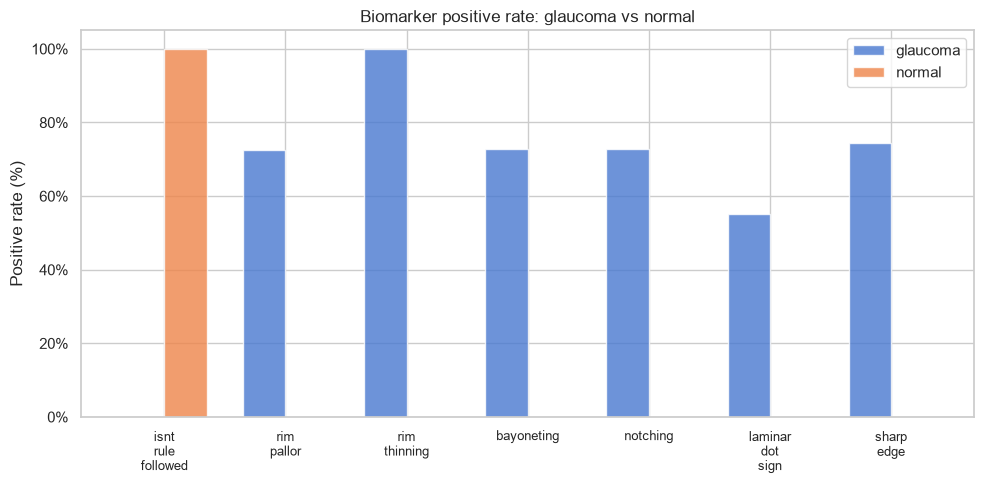

In [ ]:
bool_cols = [
    "isnt_rule_followed", "rim_pallor", "rim_thinning",
    "bayoneting", "notching", "laminar_dot_sign", "sharp_edge"
]
 
# convert to bool
for c in bool_cols:
    master[c] = master[c].map(
        {True: True, False: False, "True": True, "False": False,
         "true": True, "false": False}
    )
 
freq = (
    master.groupby("annotation")[bool_cols]
    .apply(lambda x: x.mean() * 100)
    .T.round(1)
)
freq.columns.name = None
print("=== Biomarker 阳性率 (%) ===")
print(freq)
 
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(bool_cols))
w = 0.35
cols = freq.columns.tolist()
ax.bar(x - w/2, freq[cols[0]], w, label=cols[0], alpha=0.8)
if len(cols) > 1:
    ax.bar(x + w/2, freq[cols[1]], w, label=cols[1], alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels([c.replace("_", "\n") for c in bool_cols], fontsize=9)
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
ax.set_ylabel("Positive rate (%)")
ax.set_title("Biomarker positive rate: glaucoma vs normal")
ax.legend()
plt.tight_layout()
plt.savefig("kg_output/biomarker_frequency.png", dpi=150)
plt.show()

# Biomarker 阳性率分析

=== Risk level 分布 ===
risk_assessment  healthy  high risk  moderate risk  very healthy
annotation                                                      
glaucoma               0        381             46             0
normal                 7          0              0           255


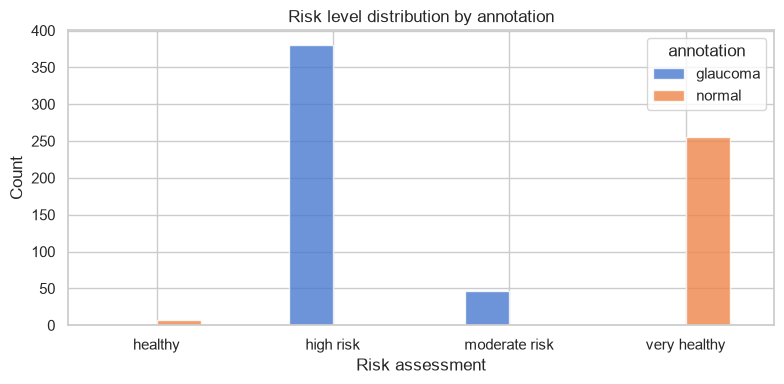

In [ ]:
risk_ct = master.groupby(["annotation", "risk_assessment"]).size().unstack(fill_value=0)
print("=== Risk level 分布 ===")
print(risk_ct)
 
risk_ct.T.plot(kind="bar", figsize=(8, 4), alpha=0.8)
plt.title("Risk level distribution by annotation")
plt.xlabel("Risk assessment")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("kg_output/risk_distribution.png", dpi=150)
plt.show()

# Risk level 分布

=== Confidence 统计 ===
            count   mean    std  min   25%   50%   75%   max
annotation                                                  
glaucoma    427.0  0.890  0.030  0.8  0.90  0.90  0.90  0.95
normal      262.0  0.947  0.024  0.9  0.95  0.95  0.95  1.00


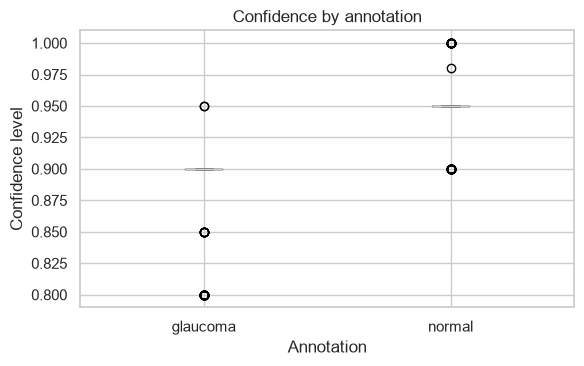

In [ ]:
master["confidence"] = pd.to_numeric(master["confidence"], errors="coerce")
 
print("=== Confidence 统计 ===")
print(master.groupby("annotation")["confidence"].describe().round(3))
 
master.boxplot(column="confidence", by="annotation", figsize=(6, 4))
plt.title("Confidence by annotation")
plt.suptitle("")
plt.xlabel("Annotation")
plt.ylabel("Confidence level")
plt.tight_layout()
plt.savefig("kg_output/confidence_distribution.png", dpi=150)
plt.show()

# Confidence 分布

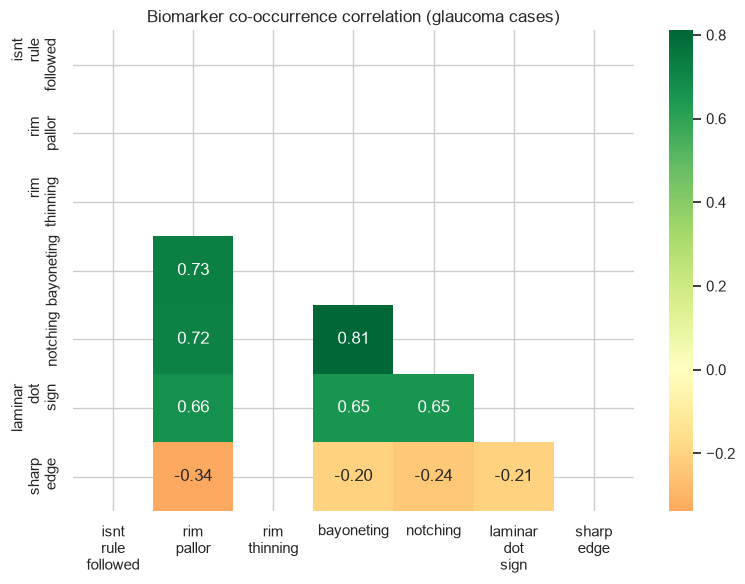

In [11]:
glaucoma = master[master.annotation == "glaucoma"][bool_cols].astype(float)
 
fig, ax = plt.subplots(figsize=(8, 6))
corr = glaucoma.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, mask=mask, annot=True, fmt=".2f",
    cmap="RdYlGn", center=0, ax=ax,
    xticklabels=[c.replace("_", "\n") for c in bool_cols],
    yticklabels=[c.replace("_", "\n") for c in bool_cols],
)
ax.set_title("Biomarker co-occurrence correlation (glaucoma cases)")
plt.tight_layout()
plt.savefig("kg_output/biomarker_cooccurrence.png", dpi=150)
plt.show()

# Biomarker 共现分析

In [12]:
total      = len(master)
g_count    = (master.annotation == "glaucoma").sum()
n_count    = (master.annotation == "normal").sum()
cdr_thresh = (master[master.annotation == "glaucoma"]["cup_to_disc_ratio"] >= 0.7).mean() * 100
isnt_viol  = (~master[master.annotation == "glaucoma"]["isnt_rule_followed"]).mean() * 100
 
print("=" * 50)
print("数据集统计汇总")
print("=" * 50)
print(f"总样本数        : {total:,}")
print(f"  glaucoma      : {g_count:,} ({g_count/total*100:.1f}%)")
print(f"  normal        : {n_count:,} ({n_count/total*100:.1f}%)")
print(f"\nGlaucoma 中 CDR ≥ 0.7  : {cdr_thresh:.1f}%")
print(f"Glaucoma 中 ISNT 违反  : {isnt_viol:.1f}%")
print(f"\n图表已保存至 kg_output/")

# 结果汇总，真无聊

数据集统计汇总
总样本数        : 689
  glaucoma      : 427 (62.0%)
  normal        : 262 (38.0%)

Glaucoma 中 CDR ≥ 0.7  : 99.8%
Glaucoma 中 ISNT 违反  : 100.0%

图表已保存至 kg_output/
